In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# This dataset has encoding issues — latin-1 fixes it
df = pd.read_csv('../Data/spam.csv', encoding='latin-1')

# Keep only useful columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print(df.shape)
print(df.head())
print(df['label'].value_counts())
print(df.isnull().sum())

(5572, 2)
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
label
ham     4825
spam     747
Name: count, dtype: int64
label      0
message    0
dtype: int64


       msg_length  word_count
label                        
ham     71.023627   14.200622
spam   138.866131   23.851406


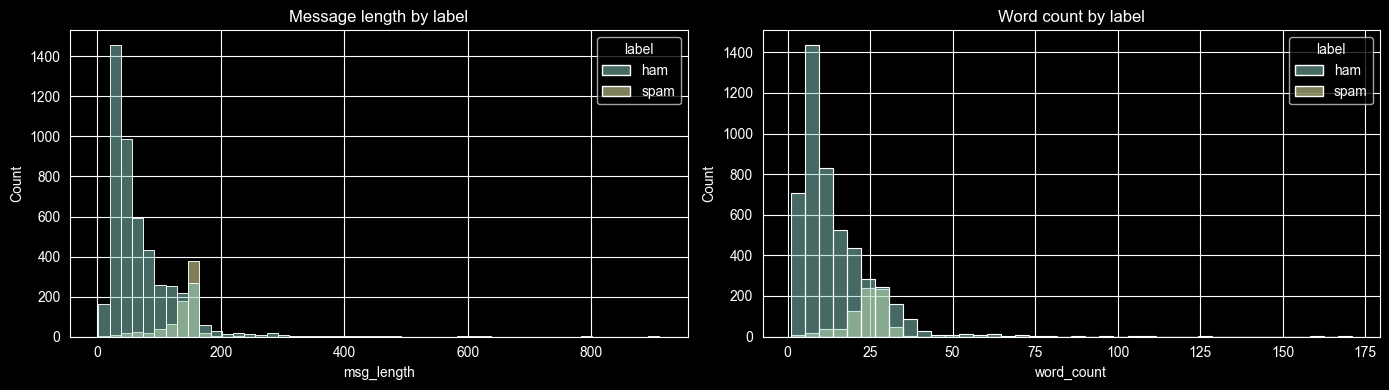

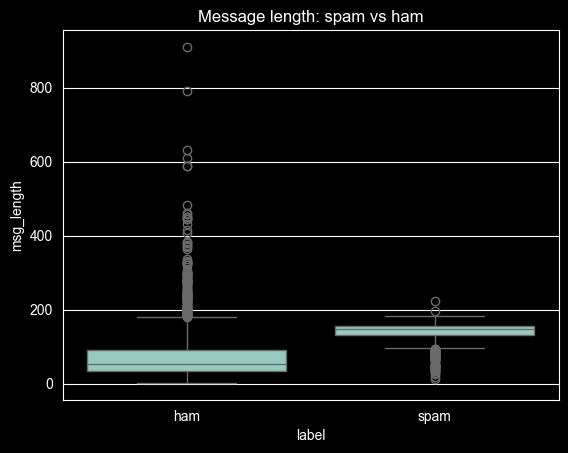

In [2]:
# Message length analysis
df['msg_length'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

print(df.groupby('label')[['msg_length', 'word_count']].mean())

# Length distribution by label
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(data=df, x='msg_length', hue='label', bins=50, ax=axes[0])
axes[0].set_title('Message length by label')

sns.histplot(data=df, x='word_count', hue='label', bins=40, ax=axes[1])
axes[1].set_title('Word count by label')

plt.tight_layout()
plt.show()

# Boxplot
sns.boxplot(data=df, x='label', y='msg_length')
plt.title('Message length: spam vs ham')
plt.show()

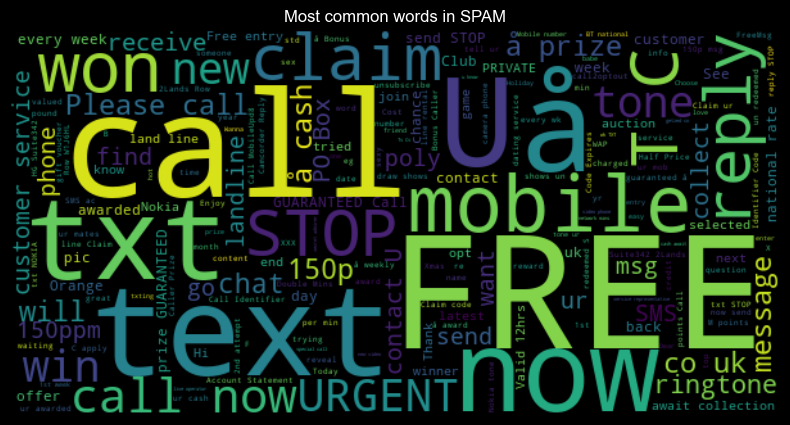

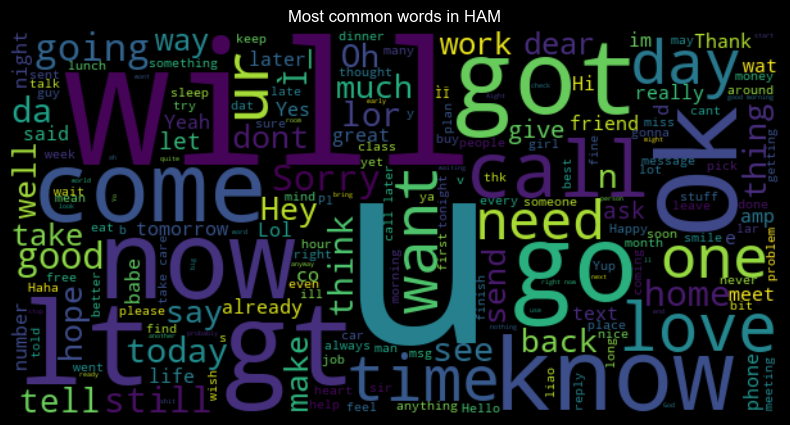

In [3]:
from wordcloud import WordCloud

# Separate spam and ham messages
spam_text = ' '.join(df[df['label'] == 'spam']['message'])
ham_text  = ' '.join(df[df['label'] == 'ham']['message'])

# Spam wordcloud
wc_spam = WordCloud(width=600, height=300, background_color='black').generate(spam_text)
plt.figure(figsize=(10, 5))
plt.imshow(wc_spam, interpolation='bilinear')
plt.axis('off')
plt.title('Most common words in SPAM')
plt.show()

# Ham wordcloud
wc_ham = WordCloud(width=600, height=300, background_color='black').generate(ham_text)
plt.figure(figsize=(10, 5))
plt.imshow(wc_ham, interpolation='bilinear')
plt.axis('off')
plt.title('Most common words in HAM')
plt.show()

In [4]:
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import joblib

# Text cleaning function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()
    return text

df['clean_msg'] = df['message'].apply(clean_text)
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

# TF-IDF — converts text to numbers
tfidf = TfidfVectorizer(max_features=3000, stop_words='english')
X = tfidf.fit_transform(df['clean_msg'])
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train 2 models
models = {
    'Naive Bayes':        MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"\n{'='*40}")
    print(f"  {name}")
    print('='*40)
    print(classification_report(y_test, preds, target_names=['Ham', 'Spam']))


  Naive Bayes
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       0.99      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115


  Logistic Regression
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       0.99      0.73      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.96      0.96      0.96      1115



In [5]:
joblib.dump(models['Naive Bayes'], '../Models/model.pkl')
joblib.dump(tfidf, '../Models/tfidf.pkl')
print("Saved.")

Saved.
